In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("fraud-detection-project/creditcard.csv")
print(df.shape)

(284807, 31)


In [2]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [3]:
df["Amount"].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

In [4]:
df.groupby("Class")["Amount"].mean()

Class
0     88.291022
1    122.211321
Name: Amount, dtype: float64

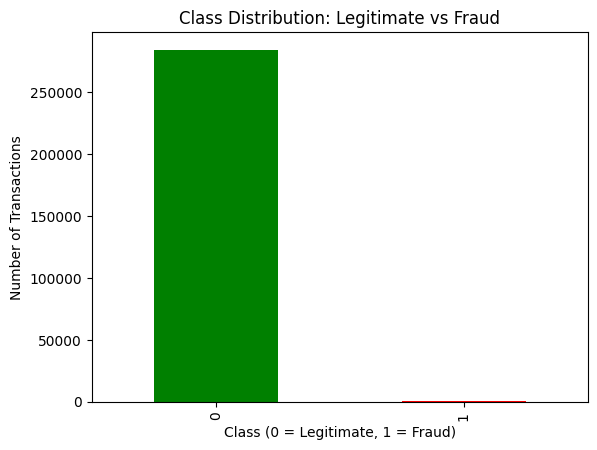

In [5]:
import matplotlib.pyplot as plt

df["Class"].value_counts().plot(kind="bar", color=["green", "red"])
plt.title("Class Distribution: Legitimate vs Fraud")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.savefig("class_imbalance.png", dpi=300, bbox_inches="tight")
plt.show()

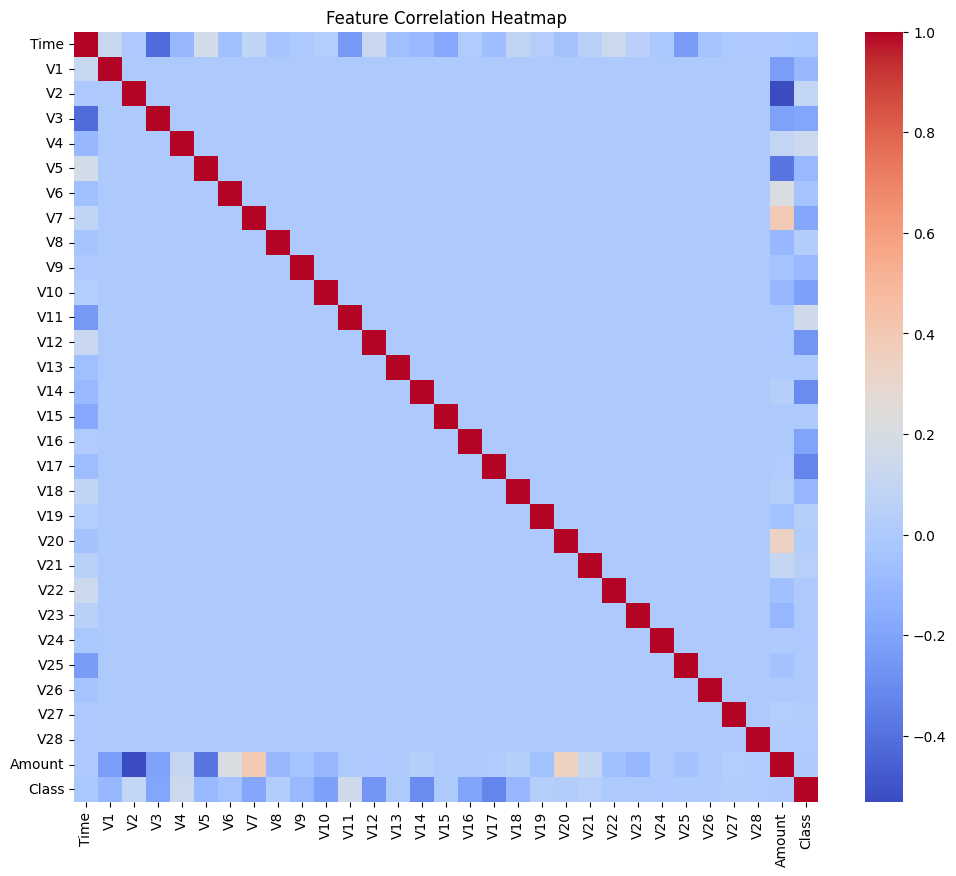

In [6]:
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
correlations = df.corr()["Class"].sort_values()
print(correlations)

V17      -0.326481
V14      -0.302544
V12      -0.260593
V10      -0.216883
V16      -0.196539
V3       -0.192961
V7       -0.187257
V18      -0.111485
V1       -0.101347
V9       -0.097733
V5       -0.094974
V6       -0.043643
Time     -0.012323
V24      -0.007221
V13      -0.004570
V15      -0.004223
V23      -0.002685
V22       0.000805
V25       0.003308
V26       0.004455
Amount    0.005632
V28       0.009536
V27       0.017580
V8        0.019875
V20       0.020090
V19       0.034783
V21       0.040413
V2        0.091289
V4        0.133447
V11       0.154876
Class     1.000000
Name: Class, dtype: float64


In [8]:
import pandas as pd
import numpy as np

df = pd.read_csv("fraud-detection-project/creditcard.csv")
print(df.shape)

(284807, 31)


In [9]:
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [10]:
df.isnull().sum()


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(1081)

In [12]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 1081


In [13]:
print("Before:", df.shape)

df = df.drop_duplicates()

print("After:", df.shape)
print("Duplicates now:", df.duplicated().sum())


Before: (284807, 31)
After: (283726, 31)
Duplicates now: 0


In [14]:
X = df.drop("Class", axis=1)
y = df["Class"]
print("Features (X):", X.shape)
print("Target (y):", y.shape)

Features (X): (283726, 30)
Target (y): (283726,)


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling done!")
print("Shape:", X_scaled.shape)


Scaling done!
Shape: (283726, 30)


In [16]:
import numpy as np

# Before scaling - original Amount column
print("BEFORE scaling - Amount range:")
print("Min:", X["Amount"].min(), " Max:", X["Amount"].max())

# After scaling - same column
print("\nAFTER scaling - Amount range:")
print("Min:", X_scaled[:, -1].min().round(2), " Max:", X_scaled[:, -1].max().round(2))


BEFORE scaling - Amount range:
Min: 0.0  Max: 25691.16

AFTER scaling - Amount range:
Min: -0.35  Max: 102.25


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (226980, 30)
Testing set: (56746, 30)


In [18]:
print("Training fraud %:", (y_train.sum() / len(y_train) * 100).round(3))
print("Testing fraud %:", (y_test.sum() / len(y_test) * 100).round(3))

Training fraud %: 0.167
Testing fraud %: 0.167


In [19]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", X_train.shape)
print("After SMOTE:", X_train_balanced.shape)
print(y_train_balanced.value_counts())

Before SMOTE: (226980, 30)
After SMOTE: (453204, 30)
Class
0    226602
1    226602
Name: count, dtype: int64
